In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar

In [2]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=10,adc_last_gap=10)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 50)
chip.add_compiler("../compiler/code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 60254
正在编译文件:  ../compiler/code/read_point3.txt
正在编译文件:  ../compiler/code/read_point3_col.txt
正在编译文件:  ../compiler/code/row_read_point3.txt
正在编译文件:  ../compiler/code/set_reset.txt
正在编译文件:  ../compiler/code/write_verify.txt
正在编译文件:  ../compiler/code/汇编测试代码.txt
正在编译文件:  ../compiler/code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../compiler/code/读单点测试.txt


In [ ]:
pos = np.zeros((256,256))
pos[128,128]=1
vans = []
vread = np.array([i for i in range(1,20)])*0.01
condans = []

for v in vread:
    voltage_base_point_row = chip.read_point2(crossbar=pos,read_voltage=0,tg=5,gain=2,from_row=True,out_type=0)
    voltage_point_row = chip.read_point2(crossbar=pos,read_voltage=v,tg=5,gain=2,from_row=True,out_type=0)
    vtmp = (voltage_point_row)
    vans.append(vtmp[128,128])
    cond0_sub_base = chip.voltage_to_cond(voltage=voltage_point_row)
    condans.append(cond0_sub_base[128,128])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(vread,vans)
plt.subplot(1,2,2)
plt.plot(vread,condans)
plt.show()

### 1.16路并行读

In [ ]:
from_row = False
voltage_base0=chip.read_chunk_parallel2(0,256,0,256,read_voltage=0,tg=5,gain=1,from_row=from_row,out_type=0,
                                        )
                                        # tia_split=[0,1,2,3,0,1,2,3,0,1,2,3,0,1,2,3])
                                        # tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3])
voltage0 = chip.read_chunk_parallel2(0,256,0,256,read_voltage=0.1,tg=5,gain=1,from_row=from_row,out_type=0,use_last_data=True)

In [ ]:
plot_cond(voltage_base0,title="voltage_parallel",label="v",vmin=0,vmax=0.05)
plot_cond(voltage0-voltage_base0,title="voltage_parallel",label="v",vmin=0,vmax=0.2)

In [ ]:
cond0_sub_base = chip.voltage_to_cond(voltage=voltage0-voltage_base0)
plot_cond(cond0_sub_base,title="cond_parallel_sub_base")
cond0 = chip.voltage_to_cond(voltage=voltage0)
plot_cond(cond0,title="cond_parallel")

In [ ]:
# voltage_base0 = chip.read_crossbar2(row_index=[i for i in range(256)],col_index=[i for i in range(256)]
#                               ,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
# voltage0 = chip.read_crossbar2(row_index=[i for i in range(256)],col_index=[i for i in range(256)]
#                               ,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)

In [ ]:
# voltage_base0 = chip.read_parallel2(crossbar=np.ones((256,256)),read_voltage=0,tg=5,gain=1,from_row=True,out_type=0,tia_split=None)
# voltage0 = chip.read_parallel2(crossbar=np.ones((256,256)),read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0,tia_split=None,use_last_data=True)

### 2.逐点读

In [3]:
chip.clk_manager.set_cyc(20, 50)
voltage_base_point_row = chip.read_point2(crossbar=np.ones((256,256)),read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row = chip.read_point2(crossbar=np.ones((256,256)),read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)

# voltage_base_point_col = chip.read_point2(crossbar=np.ones((256,256)),read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
# voltage_point_col = chip.read_point2(crossbar=np.ones((256,256)),read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)

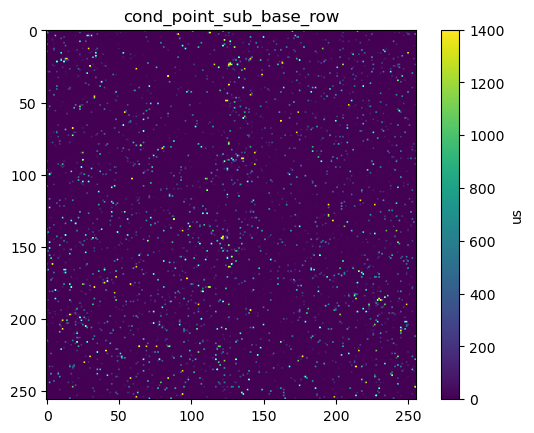

In [4]:
cond_sub_base_row = chip.voltage_to_cond(voltage=voltage_point_row-voltage_base_point_row)
plot_cond(cond_sub_base_row,title="cond_point_sub_base_row")

# cond_sub_base_col = chip.voltage_to_cond(voltage=voltage_point_col-voltage_base_point_col)
# plot_cond(cond_sub_base_col,title="cond_point_sub_base_col")
# cond_col = chip.voltage_to_cond(voltage=voltage_point_col)
# plot_cond(cond_col,title="cond_point_col")

In [ ]:
# chip.write_point2(crossbar=np.ones((256,256)),write_voltage=3,tg=5,pulse_width=100e-6,set_device=False)
voltage_base_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a-voltage_base_point_row_a)
plot_cond(cond_sub_base_row_a,title="cond_point_sub_base_row_a")
# cond_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a)
# plot_cond(cond_row_a,title="cond_point_row_a")


In [ ]:
# time.sleep(5)
voltage_base_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row_a = chip.read_point3(0,256,0,256,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a-voltage_base_point_row_a)
plot_cond(cond_sub_base_row_a,title="before forming")
# voltage_base_point_col_a = chip.read_point3(0,256,0,256,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
# voltage_point_col_a = chip.read_point3(0,256,0,256,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)


In [ ]:
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_base_point_row_a)
plot_cond(cond_sub_base_row_a,title="cond_point_sub_base_row_a")

In [ ]:
cond_sub_base_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a-voltage_base_point_row_a)
plot_cond(cond_sub_base_row_a,title="cond_point_sub_base_row_a")
cond_row_a = chip.voltage_to_cond(voltage=voltage_point_row_a)
plot_cond(cond_row_a,title="cond_point_row_a")

# cond_sub_base_col_a = chip.voltage_to_cond(voltage=voltage_point_col_a-voltage_base_point_col_a)
# plot_cond(cond_sub_base_col_a,title="cond_point_sub_base_col_a")
# cond_col_a = chip.voltage_to_cond(voltage=voltage_point_col_a)
# plot_cond(cond_col_a,title="cond_point_col_a")

In [ ]:
print(chip.clk_manager.get_program_run_time())